# KDD Data Analysis and Attack Classification using Machine Learning & Neural Networks
This notebook covers data preprocessing, feature engineering, and training multiple ML models to classify attacks using the KDD dataset.

In [10]:

import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Importing classification models
from sklearn.svm import SVC  # Importing Support Vector Classifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics
import tensorflow as tf  # TensorFlow for deep learning
from tensorflow import keras  # Keras API for building models
from tensorflow.keras.models import Sequential  # Sequential model type
from tensorflow.keras.layers import Dense, Dropout  # Neural network layers


## Load the KDD dataset from URL

In [11]:
from sklearn.datasets import fetch_kddcup99
import pandas as pd

data = fetch_kddcup99(as_frame=True) # Removed percent10=True to load the full dataset

df = data.frame
df.columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
              "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations", "num_shells",
              "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
              "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
              "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
              "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

print(df.head())

  duration protocol_type  service   flag src_bytes dst_bytes land  \
0        0        b'tcp'  b'http'  b'SF'       181      5450    0   
1        0        b'tcp'  b'http'  b'SF'       239       486    0   
2        0        b'tcp'  b'http'  b'SF'       235      1337    0   
3        0        b'tcp'  b'http'  b'SF'       219      1337    0   
4        0        b'tcp'  b'http'  b'SF'       217      2032    0   

  wrong_fragment urgent hot  ... dst_host_srv_count dst_host_same_srv_rate  \
0              0      0   0  ...                  9                    1.0   
1              0      0   0  ...                 19                    1.0   
2              0      0   0  ...                 29                    1.0   
3              0      0   0  ...                 39                    1.0   
4              0      0   0  ...                 49                    1.0   

  dst_host_diff_srv_rate dst_host_same_src_port_rate  \
0                    0.0                        0.11   
1   

In [12]:
df.shape # Load the KDD dataset and sample 5000 rows for model training and evaluation

(494021, 42)

## Data Preprocessing & Feature Engineering

In [13]:
# Encoding categorical variables into numeric form
encoder = LabelEncoder()
categorical_columns = ['protocol_type', 'service', 'flag']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Convert labels into binary classification (attack or normal) string labels first
df['label'] = df['label'].apply(lambda x: 'normal' if x == b'normal.' else 'attack')

print("\nLabel distribution before sampling:")
print(df['label'].value_counts())

# Sample 5000 rows using stratified sampling to ensure both classes are present
# Use train_test_split for stratified sampling if the dataset is large
# Here, we aim for a fixed size of 5000, so we calculate the fraction.
# If the dataset size is less than 5000, we'll just use the full dataset.

if len(df) > 5000:
    _, df_sampled = train_test_split(df, test_size=5000/len(df), stratify=df['label'], random_state=42)
    df = df_sampled.copy()
else:
    print("\nDataset already has 5000 or fewer rows, no further sampling applied.")

print("\nLabel distribution after stratified sampling (n=5000 if original was larger):")
print(df['label'].value_counts())

# Now, encode the binary string labels into numeric form (0 and 1)
df['label'] = encoder.fit_transform(df['label'])

# Feature Engineering: Creating new features
df['byte_ratio'] = df['src_bytes'] / (df['dst_bytes'] + 1)
df['total_count'] = df['count'] + df['srv_count']
df['error_rate'] = (df['serror_rate'] + df['rerror_rate']) / 2

df.head()


Label distribution before sampling:
label
attack    396743
normal     97278
Name: count, dtype: int64

Label distribution after stratified sampling (n=5000 if original was larger):
label
attack    4015
normal     985
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,byte_ratio,total_count,error_rate
157348,0,0,14,9,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
254626,0,0,14,9,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1020,0.0
175798,0,0,14,9,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1022,0.0
18734,0,1,50,9,1178,331,0,0,0,0,...,0.01,0.01,0.0,0.0,0.0,0.0,1,3.548193,2,0.0
259681,0,0,14,9,1032,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0,1032.0,1020,0.0


## Splitting Data into Training and Testing Sets

In [14]:

X = df.drop('label', axis=1)
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Training Machine Learning Models
Random Forest Classifiers:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

Gradient Boosting Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

Support Vector Classifier:
https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

model_results = {}

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

model_results['Random Forest'] = {
    'Accuracy': rf_accuracy,
    'Precision': rf_precision,
    'Recall': rf_recall,
    'F1 Score': rf_f1
}

print("Random Forest Accuracy:", rf_accuracy)
print(classification_report(y_test, y_pred_rf))


# Gradient Boosting Classifier
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb, average='weighted')
gb_recall = recall_score(y_test, y_pred_gb, average='weighted')
gb_f1 = f1_score(y_test, y_pred_gb, average='weighted')

model_results['Gradient Boosting'] = {
    'Accuracy': gb_accuracy,
    'Precision': gb_precision,
    'Recall': gb_recall,
    'F1 Score': gb_f1
}

print("Gradient Boosting Accuracy:", gb_accuracy)
print(classification_report(y_test, y_pred_gb))


# Support Vector Machine
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

model_results['SVM'] = {
    'Accuracy': svm_accuracy,
    'Precision': svm_precision,
    'Recall': svm_recall,
    'F1 Score': svm_f1
}

print("SVM Accuracy:", svm_accuracy)
print(classification_report(y_test, y_pred_svm))

Random Forest Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       1.00      1.00      1.00       202

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Gradient Boosting Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       0.99      1.00      0.99       202

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

SVM Accuracy: 0.993
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       798
           1       0.98      0.99      0.98       202

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99 

## Building a Neural Network Classifier

In [16]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9222 - loss: 0.2665 - val_accuracy: 0.9900 - val_loss: 0.0427
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9820 - loss: 0.0769 - val_accuracy: 0.9920 - val_loss: 0.0224
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9893 - loss: 0.0500 - val_accuracy: 0.9930 - val_loss: 0.0168
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9918 - loss: 0.0434 - val_accuracy: 0.9960 - val_loss: 0.0133
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9927 - loss: 0.0290 - val_accuracy: 0.9980 - val_loss: 0.0117
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9942 - loss: 0.0253 - val_accuracy: 0.9970 - val_loss: 0.0123
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9952 - loss: 0.0173 - val_accuracy: 0.9950 - val_loss: 0.0140
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9967 - loss: 0.0200 - val_accuracy: 0.

## Evaluating Neural Network Performance

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Neural Network Accuracy: 0.995
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       798
           1       0.98      1.00      0.99       202

    accuracy                           0.99      1000
   macro avg       0.99      1.00      0.99      1000
weighted avg       1.00      0.99      1.00      1000



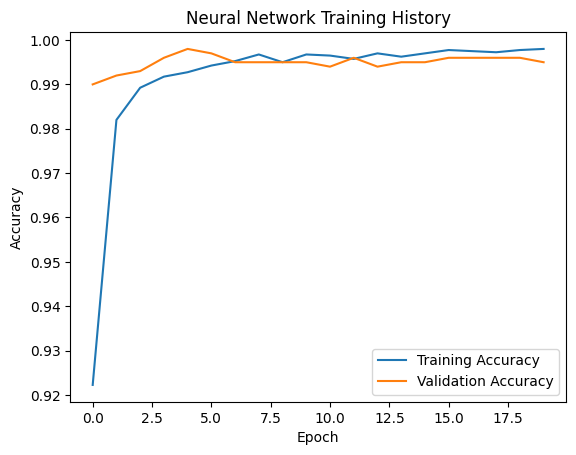

In [17]:
y_pred_nn = (model.predict(X_test) > 0.5).astype("int32")

nn_accuracy = accuracy_score(y_test, y_pred_nn)
nn_precision = precision_score(y_test, y_pred_nn, average='weighted')
nn_recall = recall_score(y_test, y_pred_nn, average='weighted')
nn_f1 = f1_score(y_test, y_pred_nn, average='weighted')

model_results['Neural Network'] = {
    'Accuracy': nn_accuracy,
    'Precision': nn_precision,
    'Recall': nn_recall,
    'F1 Score': nn_f1
}

print("Neural Network Accuracy:", nn_accuracy)
print(classification_report(y_test, y_pred_nn))

# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Neural Network Training History')
plt.show()

## Comparing Model Performance

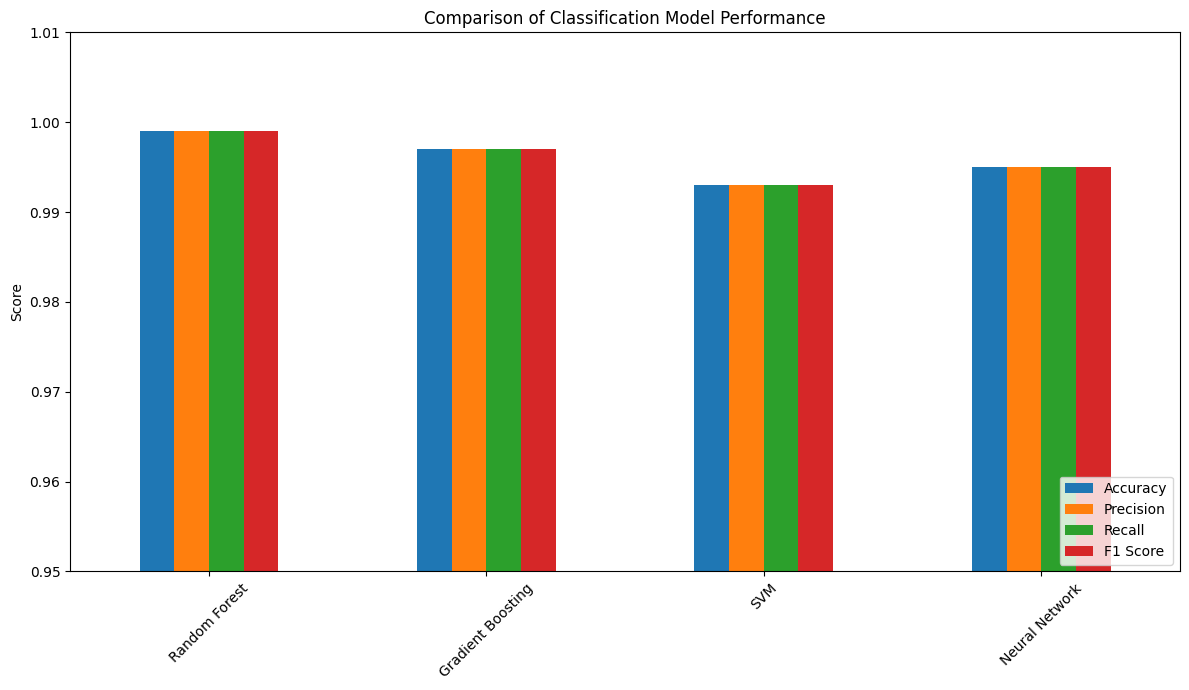

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

metrics_df = pd.DataFrame(model_results).T
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

fig, ax = plt.subplots(figsize=(12, 7))
metrics_df.plot(kind='bar', ax=ax, rot=45)

ax.set_title('Comparison of Classification Model Performance')
ax.set_ylabel('Score')
ax.set_ylim(0.95, 1.01)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Comparing Model Performance

Based on the above code, write your own code to develop other ML or Neural network algorithms from list below.

Machine Learning Algorithms
**bold text**
Decision Tree Classifier:  https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

K-Nearest Neighbors (KNN):  https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

Naive Bayes Classifier: https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html


**Deep Learning Models**
Long Short-Term Memory (LSTM): https://keras.io/api/layers/recurrent_layers/lstm/

Convolutional Neural Networks (CNN): https://keras.io/api/layers/convolution_layers/convolution1d/

Transformers (Hugging Face Transformers)

**Important: Lab-Logbbok requirement**

Provide a bar graph comparing accuracy, precicion, recall, and f-score for various AI models

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

model_results['Decision Tree'] = {
    'Accuracy': dt_accuracy,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'F1 Score': dt_f1
}

print("Decision Tree Accuracy:", dt_accuracy)
print(classification_report(y_test, y_pred_dt))


# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

model_results['Logistic Regression'] = {
    'Accuracy': lr_accuracy,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'F1 Score': lr_f1
}

print("Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(y_test, y_pred_lr))


# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb, average='weighted')
nb_recall = recall_score(y_test, y_pred_nb, average='weighted')
nb_f1 = f1_score(y_test, y_pred_nb, average='weighted')

model_results['Naive Bayes'] = {
    'Accuracy': nb_accuracy,
    'Precision': nb_precision,
    'Recall': nb_recall,
    'F1 Score': nb_f1
}

print("Naive Bayes Accuracy:", nb_accuracy)
print(classification_report(y_test, y_pred_nb))

Decision Tree Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       0.99      1.00      0.99       202

    accuracy                           1.00      1000
   macro avg       0.99      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

Logistic Regression Accuracy: 0.995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       798
           1       0.99      0.99      0.99       202

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       1.00      0.99      1.00      1000

Naive Bayes Accuracy: 0.967
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       798
           1       0.94      0.89      0.92       202

    accuracy                           0.97      1000
   macro avg       0.96      0.94 

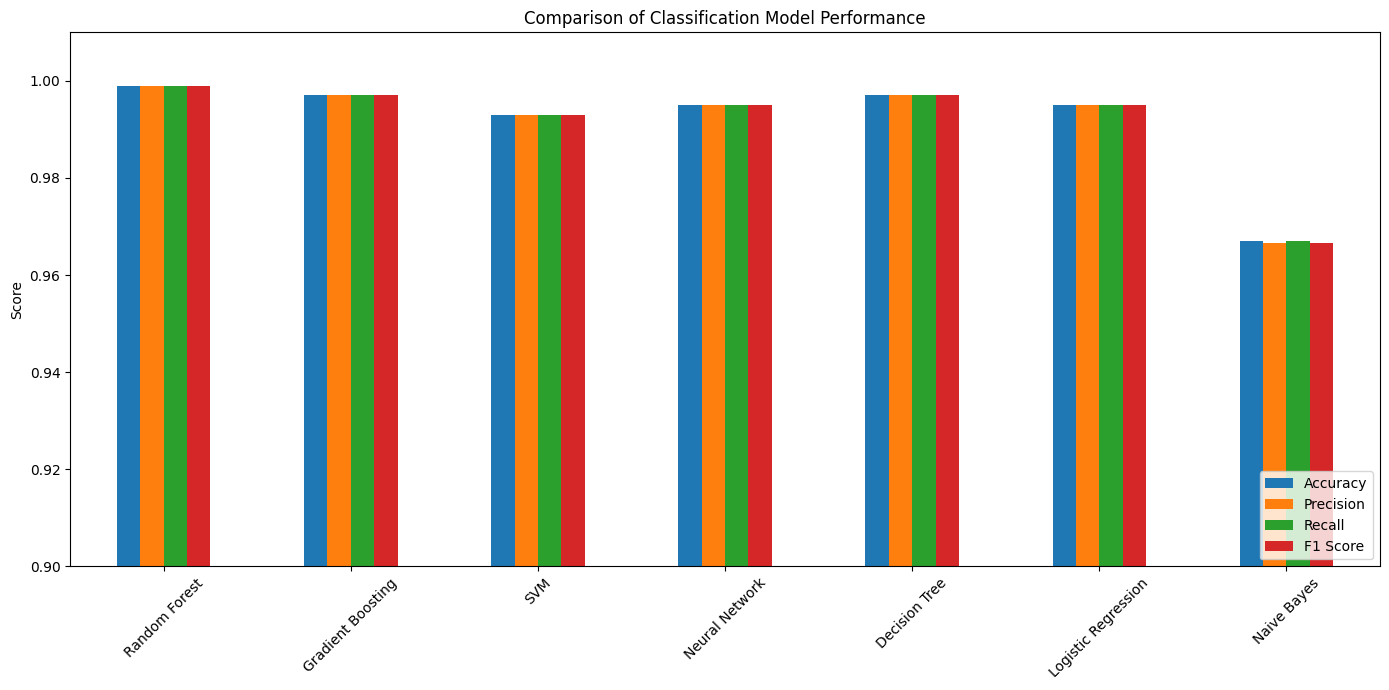

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

metrics_df = pd.DataFrame(model_results).T
metrics_df = metrics_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

fig, ax = plt.subplots(figsize=(14, 7))
metrics_df.plot(kind='bar', ax=ax, rot=45)

ax.set_title('Comparison of Classification Model Performance')
ax.set_ylabel('Score')
ax.set_ylim(0.90, 1.01)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()